# Imports

In [94]:
from langchain_groq import ChatGroq # for LLM
from langchain_huggingface.embeddings import HuggingFaceEmbeddings # for embeddings model
from langchain.tools import tool # for custome tools
from langchain_community.document_loaders.csv_loader import CSVLoader # for loading csv file
from langchain_text_splitters import RecursiveCharacterTextSplitter # for chunking data
from langchain_community.vectorstores import FAISS # for vector db
from langchain_core.messages import SystemMessage, BaseMessage, HumanMessage, AIMessage, ToolMessage # for messaging type
from langgraph.graph.message import add_messages # for message adding
from langgraph.prebuilt import ToolNode, tools_condition # for tools conditions
from langchain_tavily import TavilySearch # for web search
# for langgraph workflow
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List
import os
# env
from dotenv import load_dotenv
load_dotenv("../.env")

True

# Model

In [95]:
llm = ChatGroq(model="llama-3.3-70b-versatile", api_key=os.getenv("GROQ_API_KEY"))
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Tools

In [102]:
rag_tools = []
web_tools = []

loading csv data

In [5]:
all_docs = []

for csv_path in ["../datasets/data_preprocessed/device_manuals.csv", "../datasets/data_preprocessed//question_answer.csv"]:
    if os.path.exists(csv_path):
        loader = CSVLoader(file_path=csv_path, encoding="latin1")
        docs = loader.load()  # Each row = 1 Document
        all_docs.extend(docs)  # Keep Document objects

chunking docs

In [6]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=500)
texts = text_splitter.split_documents(all_docs)

storing results in FAISS vector store.

In [7]:
vector_db = FAISS.from_documents(texts, embeddings)

vector search tool

In [103]:
@tool("vector_search", description="Search the device manuals and question answer database for relevant documents.")
def vector_search(query: str):
    """Retrieves top 5 results from FAISS for a given query."""
    try:
        retriever = vector_db.as_retriever(search_type='similarity', search_kwargs={'k': 5})
        result = retriever.invoke(query)
        context = "\n\n".join([doc.page_content for doc in result])
        return context
    except Exception as e:
        return f"Vector search Error: {str(e)}"
rag_tools.append(vector_search)

tavily search tool

In [104]:
@tool("website_search", description="search on web using tavily search for the latest information.")
def website_search(query):
    try:
        tavily_search_tool = TavilySearch(
            max_results=5,
            topic="general",
        )
        return tavily_search_tool.invoke("What is the capital of France?")["results"]
    except Exception as e:
        return "Travily search failed: " + str(e)

binding LLM with tools

In [105]:
llm_with_rag_tools = llm.bind_tools(rag_tools)
llm_with_web_tools = llm.bind_tools(web_tools)

# Lang graph state

In [106]:
class ChatState(TypedDict):
    question: str # question from the user
    messages: Annotated[List[BaseMessage], add_messages] # all messages history
    phase: str # current phase of the chat web or rag

# Nodes

planning node (Tells the agent what the execution workflow will be)

In [107]:
def planning(state: ChatState):

   fixed_spelling = llm.invoke(f"Fix the spelling, syntax and any other errors in the question and just give question donot give maything else: {state['question']}.").content
   SYSTEM_PROMPT = """
You are an Agentic RAG assistant.

You MUST follow these rules exactly:

1. Mandatory Vector Retrieval:
   - For EVERY user question, you MUST call the `vector_search` tool first.
   - You are NOT allowed to answer the question before calling `vector_search`.
   - Use the 'vector_search' tool just once. If the context is not retrieved properly then move on and never use this tool ever again.

2. Multi-part Query Handling:
   - If the user question contains multiple distinct inquiries (e.g., "Tell me about X and who is Y?"), you MUST ensure that you address ALL parts.
   - You may call multiple tools or call them sequentially to gather information for each part.

3. Context Evaluation:
   - After receiving the `vector_search` output, evaluate whether the context is sufficient and relevant for the ENTIRE question.

4. Web Search Escalation (ONLY if vector context is insufficient):
   - You MUST perform a web search using the most appropriate tool based on the question type.

5. Web Search Tool Selection Rules:
   - Use `website_search` for:
     - General knowledge questions.
     - Questions about current events, news, or trending topics.
     - Questions about specific people, organizations, or institutions.
     - Questions about specific products or services.
     - Or any other query that is not handled by vector search.
     
6. Tool Usage Restrictions:
   - You are ONLY allowed to use tools that have been registered.
   - DO NOT invent tool names.
   - DO NOT call unregistered tools.
   - If no suitable web search tool is available, explicitly state that more information is required.

7. Knowledge Grounding:
   - NEVER answer from internal knowledge unless you have exhausted all search tools and still have no information.
   - ALL answers SHOULD be grounded in retrieved tool context whenever possible.

8. Tool Call Format:
   - When calling a tool, output ONLY a valid tool call.
   - Do NOT include explanations, reasoning, or natural language ALONGSIDE a tool call.
   - HOWEVER, if you are refusing to answer due to safety guidelines, or if you need to provide a disclaimer, you SHOULD use natural language.

Failure to follow these rules is not allowed. Strictly follow all these rules.
REMINDER: USE vector_search TOOL JUST ONCE AND ONLY ONCE.
"""

   system = SystemMessage(
      content=SYSTEM_PROMPT  
   )
   user = HumanMessage(content=fixed_spelling)

   return {
      "messages": [system, user],
      "question": fixed_spelling,
      "phase": "rag"
   }


context search node (this node will bring the context from evaluating rag)

In [108]:
def context_search(state: ChatState):
        
    ai_response = llm_with_rag_tools.invoke(state["messages"])
    
    return {"messages": [ai_response]}


check relevence node (this node will check if the searched context from rag and web are good enough or they requre more searching)

In [109]:
def check_relevence(state: ChatState):
    
    reversed_iterator = reversed(state["messages"])
    tool_outputs = []
    
    for msg in reversed_iterator:
        if isinstance(msg, ToolMessage):
            tool_outputs.append(msg.content)

    if len(tool_outputs) >= 6:
        return {"phase": "fall_back_llm"}
            
    context_str = "\n---\n".join(reversed(tool_outputs))

    judge_prompt = f"""
    Question: {state['question']}
    Context:
    {context_str}

    Review the context above and determine if it provides a COMPLETE answer to ALL parts of the user's question: "{state['question']}".
    If ANY part of the question cannot be answered using the provided context, respond with NO.
    Only respond with YES if EVERYTHING in the question can be answered using only the provided context.
    Reply only YES or NO.
    """

    decision = llm.invoke(judge_prompt).content.strip().upper()

    if "YES" in decision:
        return {"phase": "end"}
    else:
        return {"phase": "web"}


fallback llm node

In [110]:
def fall_back_llm(state: ChatState):
    prompt = f"""
    Answer the following question using your knowledge.
    Do NOT use tools.
    Keep the answer high-level and educational.

    Question: {state['question']}
    """

    answer = llm.invoke(prompt).content

    return {
        "messages": [AIMessage(content=answer)],
        "phase": "end"
    }


web search node (this node will decide give us web search results)

In [111]:
def web_search(state: ChatState):
    
    ai_response = llm_with_web_tools.invoke(state["messages"])
    
    return {"messages": [ai_response]}


In [112]:
def should_continue_web(state: ChatState):
    """Routing function for check_relevence conditional edges"""
    return state["phase"]

# Graph

In [113]:
graph = StateGraph(ChatState)

tools node

In [114]:
rag_tool_node = ToolNode(rag_tools)
web_tool_node = ToolNode(web_tools)

creating all nodes

In [115]:
graph.add_node('planning', planning)
graph.add_node('context_search', context_search)
graph.add_node('check_relevence', check_relevence)
graph.add_node('web_search', web_search)
graph.add_node('rag_tools', rag_tool_node)
graph.add_node('web_tools', web_tool_node)
graph.add_node("fall_back_llm", fall_back_llm)

creating add edges

In [116]:
graph.add_edge(START, "planning")
graph.add_edge('planning', 'context_search')
graph.add_conditional_edges('context_search', tools_condition, {"tools": "rag_tools", "__end__": "check_relevence"})
graph.add_edge('rag_tools', 'context_search')
graph.add_conditional_edges("check_relevence", should_continue_web, {"web": "web_search", "end": END, "fall_back_llm": "fall_back_llm"})
graph.add_conditional_edges('web_search', tools_condition, {"tools": "web_tools", "__end__": "check_relevence"})
graph.add_edge("web_tools", "web_search")
graph.add_edge("fall_back_llm", END)

compiling graph

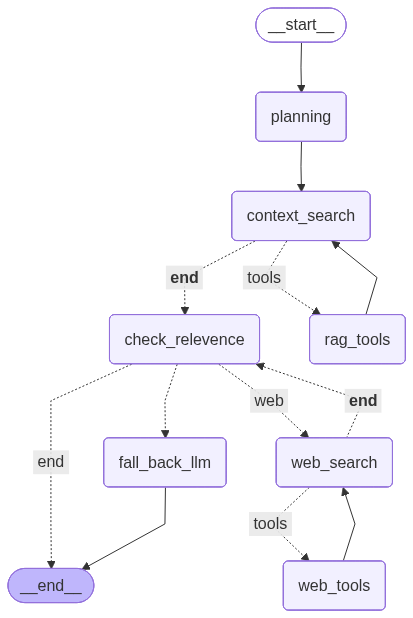

In [117]:
chatbot = graph.compile()
chatbot

# Question to agent

In [ ]:
initial_state = {
    'question': "Who is the Prime Minister of Pakistan?"
}

res = chatbot.invoke(initial_state)
res

Failed to send compressed multipart ingest: langsmith.utils.LangSmithUserError: This API key is org-scoped and requires workspace specification. Please provide 'workspace_id' parameter, or set LANGSMITH_WORKSPACE_ID environment variable.
Failed to send compressed multipart ingest: langsmith.utils.LangSmithUserError: This API key is org-scoped and requires workspace specification. Please provide 'workspace_id' parameter, or set LANGSMITH_WORKSPACE_ID environment variable.
Failed to send compressed multipart ingest: langsmith.utils.LangSmithUserError: This API key is org-scoped and requires workspace specification. Please provide 'workspace_id' parameter, or set LANGSMITH_WORKSPACE_ID environment variable.
Failed to send compressed multipart ingest: langsmith.utils.LangSmithUserError: This API key is org-scoped and requires workspace specification. Please provide 'workspace_id' parameter, or set LANGSMITH_WORKSPACE_ID environment variable.
Failed to send compressed multipart ingest: lang

KeyboardInterrupt: 

Failed to send compressed multipart ingest: langsmith.utils.LangSmithUserError: This API key is org-scoped and requires workspace specification. Please provide 'workspace_id' parameter, or set LANGSMITH_WORKSPACE_ID environment variable.


In [ ]:
ai_msg = res["messages"][-1].content
print(ai_msg)

Imran Khan is a Pakistani politician and former cricketer who served as the 22nd Prime Minister of Pakistan from August 2018 until April 2022. He is the founder and chairman of the Pakistan Tehreek-e-Insaf (PTI) party. Khan was born on October 5, 1952, in Lahore, Pakistan, and graduated from Oxford University. He played cricket for Pakistan from 1971 to 1992 and was the team's captain when they won the 1992 Cricket World Cup. Khan entered politics in the late 1990s and became a member of the National Assembly in 2002. He has been a vocal advocate for social justice, education, and healthcare reform in Pakistan. Khan's government has implemented various policies and projects aimed at improving the country's economy, infrastructure, and social services. However, his tenure as prime minister was marked by controversy, including allegations of corruption and criticism of his handling of the economy and foreign policy. Khan was ousted as prime minister in April 2022 after losing a no-confid

Failed to send compressed multipart ingest: langsmith.utils.LangSmithUserError: This API key is org-scoped and requires workspace specification. Please provide 'workspace_id' parameter, or set LANGSMITH_WORKSPACE_ID environment variable.
